# Plots

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
cost_factors = [5, 10, 15, 20, 25, 30]
N = 2**16

# import building table data
df_building = pd.read_csv(f'results/building_table_results.csv')

# compute actual cost
df_building["actual_cost"] = df_building["hashes"] + (df_building["reductions"] * (1 / 557.3))



## Plot precomputation

### num endpoints


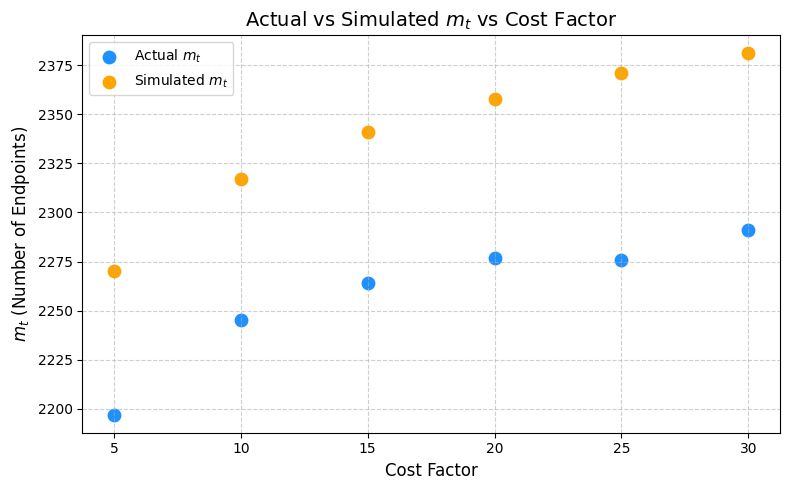

In [22]:
# Scatter plot for actual vs simulated m_t
plt.figure(figsize=(8, 5))
plt.scatter(df_building["cost_factor"], df_building["actual_mt"], color="dodgerblue", marker="o", s=80, label="Actual $m_t$")
plt.scatter(df_building["cost_factor"], df_building["simulated_mt"], color="orange", marker="o", s=80, label="Simulated $m_t$")
# plt.scatter(1, 1563, color="black", marker="o", s=80, label="Vanilla $m_t$")

# Add labels and title
plt.title("Actual vs Simulated $m_t$ vs Cost Factor", fontsize=14)
plt.xlabel("Cost Factor", fontsize=12)
plt.ylabel("$m_t$ (Number of Endpoints)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


### cost

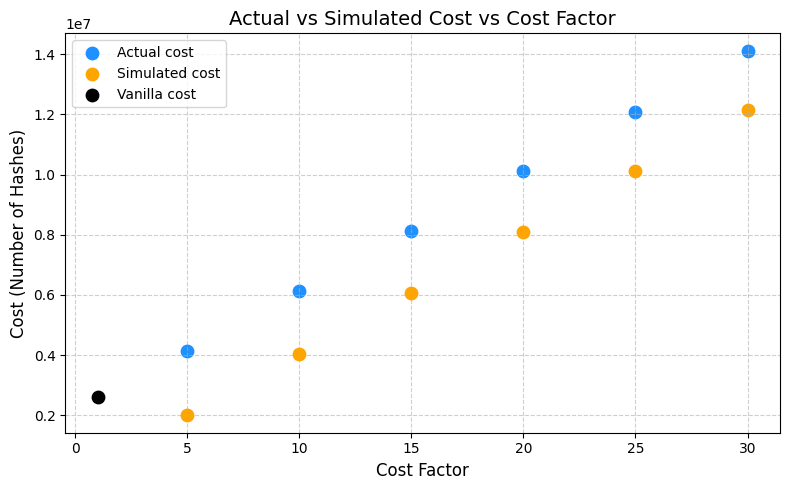

In [25]:
# Scatter plot for actual vs simulated m_t
plt.figure(figsize=(8, 5))
plt.scatter(df_building["cost_factor"], df_building["actual_cost"], color="dodgerblue", marker="o", s=80, label="Actual cost")
plt.scatter(df_building["cost_factor"], df_building["simulated_cost"], color="orange", marker="o", s=80, label="Simulated cost")
plt.scatter(1, 2600800, color="black", marker="o", s=80, label="Vanilla cost")

# Add labels and title
plt.title("Actual vs Simulated Cost vs Cost Factor", fontsize=14)
plt.xlabel("Cost Factor", fontsize=12)
plt.ylabel("Cost (Number of Hashes)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

## Searching

In [38]:
# want to store coverage, 
coverages = []
costs = []
false_alarms_true = []
false_alarms_false = []

for c in cost_factors:
    filename = f"results/searching_table_results_cost_{c}.csv"
    df = pd.read_csv(filename)

    # calculate coverage
    found_count = df["found"].sum()

    coverage = (found_count / N ) * 100

    coverages.append(coverage)

    # calculate average cost
    avg_cost = (df["hashes"].sum() + (df["reductions"] * (1 / 557.3)).sum()) / N
    costs.append(avg_cost)

    # calculate average false alarms
    false_alarm_avg = df.groupby('found')['false_alarms'].mean()
    
    # store separately for found=True and found=False
    false_alarms_true.append(false_alarm_avg.get(1, 0))   # if point was found
    false_alarms_false.append(false_alarm_avg.get(0, 0))  # if point was not found

print(false_alarms_true)
print(false_alarms_false)


for c, cov in zip(cost_factors, coverages):
    print(f"{c:<12} | {cov:>6.2f}%")

filename = f"results/searching_vanilla_table_results.csv"
df = pd.read_csv(filename)
# calculate coverage
found_count = df["found"].sum()
cost = (df["hashes"].sum() + (df["reductions"] * (1 / 557.3)).sum()) / N
print(cost)

coverage = (found_count / N ) * 100

print(coverage)

# calculate average false alarms
false_alarm_avg = df.groupby('found')['false_alarms'].mean()
print(false_alarm_avg.get(1, 0))
print(false_alarm_avg.get(0, 0))
    

C:\Users\psymf9\AppData\Local\Temp\ipykernel_20916\1693599054.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  false_alarms_true.append(false_alarm_avg.get(1, 0))   # if point was found
C:\Users\psymf9\AppData\Local\Temp\ipykernel_20916\1693599054.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  false_alarms_false.append(false_alarm_avg.get(0, 0))  # if point was not found
C:\Users\psymf9\AppData\Local\Temp\ipykernel_20916\1693599054.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame b

[np.float64(10.872652006021337), np.float64(10.637628849217963), np.float64(10.544812125347239), np.float64(10.651949104465515), np.float64(10.601757999383727), np.float64(10.709837501216308)]
[np.float64(57.91719457013575), np.float64(57.897518610421834), np.float64(57.88590098014576), np.float64(58.27284561312158), np.float64(58.062451612903224), np.float64(58.45198760970573)]
5            |  93.26%
10           |  93.85%
15           |  93.93%
20           |  94.14%
25           |  94.09%
30           |  94.09%
1726.9086152327761
85.41412353515625
11.4575986565911
52.46333298462182


C:\Users\psymf9\AppData\Local\Temp\ipykernel_20916\1693599054.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(false_alarm_avg.get(1, 0))
C:\Users\psymf9\AppData\Local\Temp\ipykernel_20916\1693599054.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(false_alarm_avg.get(0, 0))
